In [1]:
import sys
import cv2
import torch
from matplotlib import pyplot as plt
import torch
# from efficientnet_pytorch import EfficientNet
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torch import nn, optim
import numpy as np
import os
import argparse
from tqdm import tqdm
from sklearn.model_selection import train_test_split  
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import re

from PIL import Image
from torch.nn import functional as F

import cv2
import torch
import os
from tqdm import tqdm
import ptlflow
from ptlflow.utils import flow_utils
import re
import numpy as np
import concurrent.futures
import timm
import time 
import random

d:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\venv\Lib\site-packages\timm\models\layers\__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


[!!alt_cuda_corr is not compiled!!]


# Load Frames

In [2]:

frames_dir = r'D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_Cleaned\Dataset\Processed\Train\frames\\'

frames = os.listdir(frames_dir)
print(f"Total frames: {len(frames)}")


Total frames: 9135


In [3]:

def natural_sort_key(s):
    return int(re.search(r'(\d+)', s).group())

frames = sorted(os.listdir(frames_dir), key=natural_sort_key)

# Check actual frame count
print(f"Total frames: {len(frames)}")
print(f"First frame: {frames[0]}")
print(f"Last frame: {frames[-1]}")
print(f"Expected last frame: frame_{len(frames)-1}.jpg")
print(frames[:20])


Total frames: 9135
First frame: frame_0.png
Last frame: frame_9134.png
Expected last frame: frame_9134.jpg
['frame_0.png', 'frame_1.png', 'frame_2.png', 'frame_3.png', 'frame_4.png', 'frame_5.png', 'frame_6.png', 'frame_7.png', 'frame_8.png', 'frame_9.png', 'frame_10.png', 'frame_11.png', 'frame_12.png', 'frame_13.png', 'frame_14.png', 'frame_15.png', 'frame_16.png', 'frame_17.png', 'frame_18.png', 'frame_19.png']


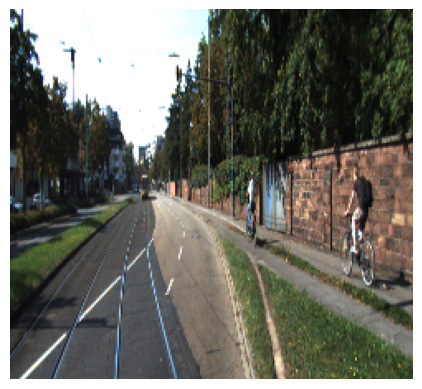

In [50]:
img = cv2.imread(os.path.join(frames_dir, frames[0]))
img = cv2.resize(img, (244, 224))   
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

# Train Test Split

In [7]:
def create__indices(folder, random_state=42):
    image_files = [f for f in os.listdir(folder) if f.startswith('frame_') and f.endswith('.png')]
    indices = [int(f.split('_')[1].split('.')[0]) for f in image_files]
    
    indices = sorted(indices)

    # random.seed(random_state)
    # random.shuffle(indices)
    return indices


train_indices = create__indices(r'D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_Cleaned\Dataset\Processed\Train\frames', random_state=42)
val_indices =   create__indices(r'D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_Cleaned\Dataset\Processed\Val\frames', random_state=42)

train_indices.remove(max(train_indices))
val_indices.remove(max(val_indices))

print(f"\nTrain indices: {train_indices[:10]} ... Total: {len(train_indices)}")
print(f"Val indices: {val_indices[:10]} ... Total: {len(val_indices)}")



Train indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] ... Total: 9134
Val indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] ... Total: 2123


# Dataloader

In [8]:

class PreprocessedSpeedDataset(Dataset):
    def __init__(self, folder, speed_file, indices=None, transform=None):
        self.folder = folder
        self.transform = transform  

        if indices:
            self.frame_files = [os.path.join(folder, f'frame_{idx}.png') for idx in indices]
        else:
            self.frame_files = [os.path.join(folder, f'frame_{idx}.png') for idx in range(len(os.listdir(folder)))]

        all_speeds = [float(speed) for speed in open(speed_file).read().splitlines()]
        self.speed_files = [all_speeds[idx+1] for idx in indices] if indices else all_speeds
        
    
    def __len__(self):
        return len(self.frame_files)
    
    def __getitem__(self, idx):
        image = plt.imread(self.frame_files[idx])[:, :, :3]  # Ensure RGB format

        speed = self.speed_files[idx]
        speed = torch.tensor(speed, dtype=torch.float32)

        if self.transform:
            image = self.transform(image)
        else:
            image = transforms.ToTensor()(image)

        return image, speed



transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224, 224)),
])



In [9]:


train_frame_dir = r"D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_Cleaned\Dataset\Processed\Train\frames"
val_frame_dir =   r"D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_Cleaned\Dataset\Processed\Val\frames"

train_speed_dir = r"D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_Cleaned\Dataset\Processed\Train\frame_speeds.txt"
val_speed_dir =   r"D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_Cleaned\Dataset\Processed\Val\frame_speeds.txt"

train_dataset = PreprocessedSpeedDataset(train_frame_dir, train_speed_dir, train_indices, transform=transform)
val_dataset = PreprocessedSpeedDataset(val_frame_dir, val_speed_dir, val_indices, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, num_workers=0, shuffle=True, pin_memory=True)   # * 64 best, 32 2nd best
val_loader = DataLoader(val_dataset, batch_size=32, num_workers=0, pin_memory=True)


IndexError: index 77 is out of bounds for dimension 0 with size 16

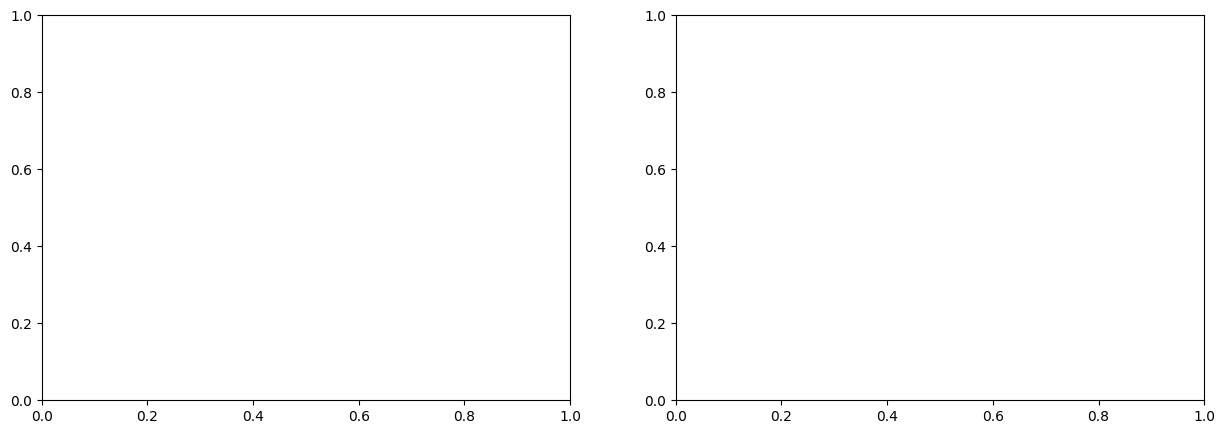

In [84]:
idx = 77
# idx = 0

# Create subplots to display frame0, frame1, flow, and speed
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# Load and display frame0
frame0_path = os.path.join(frames_dir, frames[idx])
frame0 = cv2.imread(frame0_path)
frame0_rgb = cv2.cvtColor(frame0, cv2.COLOR_BGR2RGB)
frame0 = cv2.resize(frame0, (224, 224))
frame0_processed_rgb = cv2.cvtColor(frame0, cv2.COLOR_BGR2RGB)

axs[0].imshow(frame0_processed_rgb)
axs[0].set_title('Frame 0 (Processed)')
axs[0].axis('off')

# Load and display frame1
frame1_path = os.path.join(frames_dir, frames[idx + 1])
frame1 = cv2.imread(frame1_path)
frame1 = cv2.resize(frame1, (224, 224))
frame1_processed_rgb = cv2.cvtColor(frame1, cv2.COLOR_BGR2RGB)

axs[1].imshow(frame1_processed_rgb)
axs[1].set_title('Frame 1 (Processed)')
axs[1].axis('off')

# Get speed value from dataset
speed_value = train_dataset[idx][1].item()
fig.suptitle(f'Speed: {speed_value:.2f} km/h', fontsize=16, y=1.02)

plt.tight_layout()
plt.show()

print(f"Speed value: {speed_value:.2f}")
print(f"Dataset returns: image tensor of shape {train_dataset[idx][0].shape}, speed value {speed_value}")

# Train Model

# CNN + LSTM Architecture

**Architecture Overview:**
1. **CNN Feature Extractor**: EfficientNetV2 (frozen, pretrained on ImageNet)
   - Extracts spatial features from each frame
   - Uses layer 2 features (48-64 channels, 28x28 spatial)
   
2. **Global Average Pooling**: Converts 2D features to 1D vectors
   
3. **LSTM**: Temporal modeling (2 layers, 128 hidden units)
   - Processes sequence of frame features
   - Captures motion patterns over time
   
4. **Regression Head**: Predicts speed from LSTM output
   - FC(128) → ReLU → Dropout → FC(32) → ReLU → FC(1)

**Input**: [batch, 2, 3, 224, 224] (2 consecutive frames)  
**Output**: [batch, 1] (speed prediction)

**Advantages over ConvLSTM:**
- Simpler architecture with fewer parameters
- Faster training and inference
- Uses standard PyTorch LSTM (well-optimized)
- Better for temporal relationships in feature space

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import timm
import cv2
import os
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import time
from torch.amp import autocast, GradScaler
import warnings


class ConsecutiveFramesDataset(Dataset):
    def __init__(self, folder, speed_file, indices=None, transform=None):
        self.folder = folder
        self.transform = transform
        
        if indices:
            # Remove the last index to ensure we have pairs
            self.indices = [idx for idx in indices if idx < max(indices)]
        else:
            all_files = os.listdir(folder)
            max_idx = len(all_files) - 1
            self.indices = list(range(max_idx))
        
        # Load speeds
        all_speeds = [float(speed) for speed in open(speed_file).read().splitlines()]
        self.speeds = [all_speeds[idx+1] for idx in self.indices]  # +1 for ground truth alignment
    
    def __len__(self):
        return len(self.indices)
    
    def __getitem__(self, idx):
        frame_idx = self.indices[idx]
        
        # Load consecutive frames
        frame1_path = os.path.join(self.folder, f'frame_{frame_idx}.png')
        frame2_path = os.path.join(self.folder, f'frame_{frame_idx + 1}.png')
        
        frame1 = plt.imread(frame1_path)[:, :, :3]  # RGB
        frame2 = plt.imread(frame2_path)[:, :, :3]  # RGB
        
        speed = torch.tensor(self.speeds[idx], dtype=torch.float32)
        
        if self.transform:
            frame1 = self.transform(frame1)
            frame2 = self.transform(frame2)
        else:
            frame1 = transforms.ToTensor()(frame1)
            frame2 = transforms.ToTensor()(frame2)
        
        # Stack frames: [2, 3, H, W]
        frames = torch.stack([frame1, frame2], dim=0)
        
        return frames, speed


class SpeedEstimationModel(nn.Module):
    def __init__(self, backbone='efficientnetv2_rw_t', pretrained=True, lstm_hidden_dim=128, lstm_layers=2, dropout=0.5):
        super(SpeedEstimationModel, self).__init__()
        
        # Feature extractor (CNN)
        with warnings.catch_warnings():
            warnings.filterwarnings('ignore', message='.*Unexpected keys.*pretrained weights.*')
            self.backbone = timm.create_model(backbone, pretrained=pretrained, features_only=True)
        
        # Get feature dimensions
        with torch.no_grad():
            dummy_input = torch.randn(1, 3, 224, 224)
            features = self.backbone(dummy_input)
            # Use features from middle layers for better spatial resolution
            self.feature_dim = features[2].shape[1]  # Usually around 48-64 channels
            self.feature_size = features[2].shape[2:]  # Spatial dimensions (H, W)
        
        # Global average pooling to convert spatial features to vectors
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        
        # LSTM for temporal modeling
        self.lstm = nn.LSTM(
            input_size=self.feature_dim,  # Flattened feature vector size
            hidden_size=lstm_hidden_dim,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=dropout if lstm_layers > 1 else 0,
            bidirectional=False
        )
        
        # Regression head
        self.dropout = nn.Dropout(dropout)
        self.regressor = nn.Sequential(
            nn.Linear(lstm_hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout/2),
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        # x: [batch, seq_len, channels, height, width]
        batch_size, seq_len = x.shape[:2]
        
        # Extract CNN features for each frame
        features_list = []
        for t in range(seq_len):
            frame_features = self.backbone(x[:, t])
            # Use middle layer features (index 2) for better spatial info
            feat = frame_features[2]  # [batch, channels, H, W]
            
            # Global average pooling to get feature vector
            pooled_feat = self.global_pool(feat).squeeze(-1).squeeze(-1)  # [batch, channels]
            features_list.append(pooled_feat)
        
        # Stack features: [batch, seq_len, feature_dim]
        features = torch.stack(features_list, dim=1)
        
        # Pass through LSTM
        lstm_out, (h_n, c_n) = self.lstm(features)
        # lstm_out: [batch, seq_len, hidden_dim]
        
        # Use final timestep output
        final_features = lstm_out[:, -1, :]  # [batch, hidden_dim]
        
        # Regression
        final_features = self.dropout(final_features)
        speed = self.regressor(final_features)
        
        return speed


def validate_model(model, val_loader, criterion, device):
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for frames, speeds in val_loader:
            frames = frames.to(device)
            speeds = speeds.to(device)
            
            outputs = model(frames)
            loss = criterion(outputs.squeeze(), speeds)
            val_loss += loss.item()
    
    return val_loss / len(val_loader)


In [17]:

# Update your dataset creation
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224, 224)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet normalization
])

# Remove last index to ensure consecutive pairs
train_indices_filtered = [idx for idx in train_indices if idx < max(train_indices)]
val_indices_filtered = [idx for idx in val_indices if idx < max(val_indices)]

train_dataset = ConsecutiveFramesDataset(train_frame_dir, train_speed_dir, train_indices_filtered, transform=transform)
val_dataset = ConsecutiveFramesDataset(val_frame_dir, val_speed_dir, val_indices_filtered, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0, pin_memory=True)

# Initialize model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SpeedEstimationModel(
    backbone='efficientnetv2_rw_t',  # Fast and efficient
    pretrained=True,
    lstm_hidden_dim=128,
    lstm_layers=2,
    dropout=0.5
).to(device)

# FREEZE THE BACKBONE - Only train ConvLSTM
for param in model.backbone.parameters():
    param.requires_grad = False

# Training setup
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=0.01)
# scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-6)
scheduler = optim.lr_scheduler.ReduceLROnPlateau( optimizer,  mode='min',  factor=0.3,  patience=2, verbose=True, min_lr=1e-8 )
scaler = GradScaler()

print(f"Model parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")


Unexpected keys (bn2.bias, bn2.num_batches_tracked, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Model parameters: 243,905
Training dataset size: 9132
Validation dataset size: 2121


d:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [18]:

# Training loop with L2 regularization
num_epochs = 10
best_loss = float('inf')
start_time = time.time()

train_losses = []
val_losses = []
patience_counter = 0
max_patience = 5

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')
    
    for batch_idx, (frames, speeds) in enumerate(pbar):
        frames = frames.to(device)
        speeds = speeds.to(device)
        
        optimizer.zero_grad()
        
        with autocast('cuda'):
            outputs = model(frames)
            base_loss = criterion(outputs.squeeze(), speeds)
            
            # L2 regularization for LSTM and regressor only
            l2_lambda = 0.01
            l2_reg = torch.tensor(0.0, device=device)
            for name, param in model.named_parameters():
                if ('lstm' in name or 'regressor' in name) and param.requires_grad:
                    l2_reg += torch.norm(param, 2)
            
            total_loss = base_loss + l2_lambda * l2_reg
        
        scaler.scale(total_loss).backward()
        scaler.unscale_(optimizer)
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += base_loss.item()
        pbar.set_postfix({
            'Loss': f'{base_loss.item():.4f}',
            'L2': f'{l2_reg.item():.4f}',
            'LR': f'{optimizer.param_groups[0]["lr"]:.1e}'
        })
    
    avg_train_loss = running_loss / len(train_loader)
    
    # Validation
    val_loss = validate_model(model, val_loader, criterion, device)
    
    # Track losses
    train_losses.append(avg_train_loss)
    val_losses.append(val_loss)
    
    # Step scheduler
    scheduler.step(val_loss)
    
    # Save best model
    if val_loss < best_loss:
        best_loss = val_loss
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'train_loss': avg_train_loss
        }, 'best_cnn_lstm_speed_model.pth')
        print(f"\nNew best model saved! Val Loss: {val_loss:.4f}")
    else:
        patience_counter += 1
    
    gap = val_loss - avg_train_loss
    
    print(f'Epoch {epoch+1}/{num_epochs}')
    print(f'Train Loss: {avg_train_loss:.4f}, Val Loss: {val_loss:.4f}')
    print(f'Gap: {gap:.4f}, LR: {optimizer.param_groups[0]["lr"]:.1e}')
    print(f'Patience: {patience_counter}/{max_patience}\n')
    
    # Early stopping
    if patience_counter >= max_patience:
        print(f"Early stopping: No improvement for {max_patience} epochs")
        break
    
    if gap > 15:
        print(f"Stopping: Overfitting gap too large ({gap:.2f})")
        break
    
    torch.cuda.empty_cache()

end_time = time.time()
print(f"Training completed in {(end_time - start_time)/60:.2f} minutes")
print(f"Best validation loss: {best_loss:.4f}")


Epoch 1/10: 100%|██████████| 571/571 [02:57<00:00,  3.22it/s, Loss=14.7030, L2=62.5699, LR=1.0e-04] 




New best model saved! Val Loss: 29.0621
Epoch 1/10
Train Loss: 38.3034, Val Loss: 29.0621
Gap: -9.2413, LR: 1.0e-04
Patience: 0/5



Epoch 2/10: 100%|██████████| 571/571 [02:59<00:00,  3.19it/s, Loss=15.9879, L2=62.1279, LR=1.0e-04]




New best model saved! Val Loss: 26.2156
Epoch 2/10
Train Loss: 15.6493, Val Loss: 26.2156
Gap: 10.5663, LR: 1.0e-04
Patience: 0/5



Epoch 3/10: 100%|██████████| 571/571 [03:00<00:00,  3.16it/s, Loss=21.6237, L2=61.7747, LR=1.0e-04]



...

Epoch 8/10
Train Loss: 11.2279, Val Loss: 24.6926
Gap: 13.4647, LR: 1.0e-04
Patience: 2/5



Epoch 9/10: 100%|██████████| 571/571 [03:02<00:00,  3.12it/s, Loss=8.1560, L2=60.6958, LR=1.0e-04] 




New best model saved! Val Loss: 23.3392
Epoch 9/10
Train Loss: 10.7852, Val Loss: 23.3392
Gap: 12.5540, LR: 1.0e-04
Patience: 0/5



Epoch 10/10: 100%|██████████| 571/571 [03:02<00:00,  3.13it/s, Loss=15.9609, L2=60.5851, LR=1.0e-04]




New best model saved! Val Loss: 23.2187
Epoch 10/10
Train Loss: 10.3332, Val Loss: 23.2187
Gap: 12.8855, LR: 1.0e-04
Patience: 0/5

Training completed in 37.29 minutes
Best validation loss: 23.2187


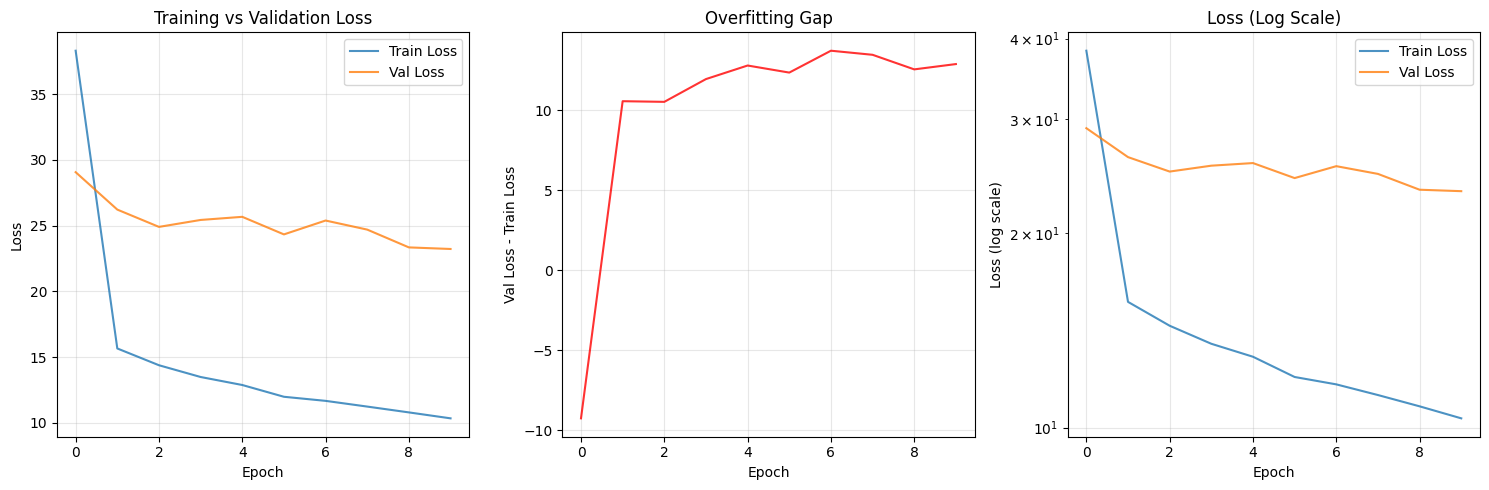

In [19]:
# Plot results
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Train Loss', alpha=0.8)
plt.plot(val_losses, label='Val Loss', alpha=0.8)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
gaps = [val - train for val, train in zip(val_losses, train_losses)]
plt.plot(gaps, color='red', alpha=0.8)
plt.xlabel('Epoch')
plt.ylabel('Val Loss - Train Loss')
plt.title('Overfitting Gap')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
if len(train_losses) > 1:
    plt.semilogy(train_losses, label='Train Loss', alpha=0.8)
    plt.semilogy(val_losses, label='Val Loss', alpha=0.8)
    plt.xlabel('Epoch')
    plt.ylabel('Loss (log scale)')
    plt.title('Loss (Log Scale)')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Simpler Training Loop

In [ ]:

# Simple Training loop (no regularization)
num_epochs = 20
best_loss = float('inf')

start_time = time.time()

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')
    
    for batch_idx, (frames, speeds) in enumerate(pbar):
        frames = frames.to(device)  # [batch, seq_len, channels, height, width]
        speeds = speeds.to(device)
        
        optimizer.zero_grad()
        
        with autocast('cuda'):
            outputs = model(frames)
            loss = criterion(outputs.squeeze(), speeds)
        
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item()
        pbar.set_postfix({
            'Loss': f'{loss.item():.4f}',
            'LR': f'{optimizer.param_groups[0]["lr"]:.1e}'
        })
        
        if batch_idx % 20 == 0:
            torch.cuda.empty_cache()
    
    avg_train_loss = running_loss / len(train_loader)
    
    # Validation
    val_loss = validate_model(model, val_loader, criterion, device)
    
    train_losses.append(avg_train_loss)
    val_losses.append(val_loss)
    
    # Step scheduler based on validation loss
    scheduler.step(val_loss)
    
    # Save best model
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'train_loss': avg_train_loss
        }, 'best_cnn_lstm_speed_model.pth')
        print(f"\nNew best model saved! Val Loss: {val_loss:.4f}")
    
    gap = val_loss - avg_train_loss
    print(f'Epoch {epoch+1}/{num_epochs}')
    print(f'Train Loss: {avg_train_loss:.4f}, Val Loss: {val_loss:.4f}, Gap: {gap:.4f}')
    print(f'LR: {optimizer.param_groups[0]["lr"]:.1e}\n')
    
    torch.cuda.empty_cache()

end_time = time.time()
print(f"Training completed in {(end_time - start_time)/60:.2f} minutes")
print(f"Best validation loss: {best_loss:.4f}")


Epoch 1/20: 100%|██████████| 571/571 [04:22<00:00,  2.18it/s, Loss=6.8398, LR=1.0e-03] 



New best model saved! Val Loss: 20.5158
Epoch 1/20
Train Loss: 20.0923, Val Loss: 20.5158
LR: 9.9e-04



Epoch 2/20: 100%|██████████| 571/571 [03:18<00:00,  2.87it/s, Loss=3.6154, LR=9.9e-04] 


Epoch 2/20
Train Loss: 4.3303, Val Loss: 24.5569
LR: 9.8e-04



Epoch 3/20:  25%|██▍       | 142/571 [00:50<02:32,  2.80it/s, Loss=2.9744, LR=9.8e-04] 


KeyboardInterrupt: 